# Step 1 (V18): SMOTE Balanced Classifier

## 🎯 Objective:
Meningkatkan frekuensi dan sensitivitas **Prediksi 1 (Sinyal Beli)** dengan menggunakan teknik **SMOTE** untuk menyeimbangkan kelas pada data training.

## ⚖️ Strategy: Option 5 - Oversampling (SMOTE)
Masalah umum dalam data pasar adalah ketidakseimbangan kelas (misal: hari turun lebih banyak dari hari naik). Hal ini membuat AI menjadi 'malas' memprediksi 1.

**Cara Kerja SMOTE:**
1.  Menganalisis fitur pada kelas 1 (minoritas).
2.  Menciptakan data baru yang serupa secara sintetis.
3.  Hasilnya, model XGBoost akan memiliki jumlah contoh 0 dan 1 yang sama banyak saat fase belajar (training).

**Hasil yang diharapkan**: AI lebih sensitif terhadap potensi kenaikan.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V18 Environment Ready (SMOTE Implementation)")

✅ V18 Environment Ready (SMOTE Implementation)


## 1. Robust Data Engineering

In [4]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)

features = features.replace([np.inf, -np.inf], np.nan).dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print("📌 Original Train Classes:")
print(y_train.value_counts())

📌 Original Train Classes:
Target
1    348
0    243
Name: count, dtype: int64


## 2. Applying SMOTE

In [5]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Applied.")
print("📌 Balanced Train Classes:")
print(pd.Series(y_train_res).value_counts())

✅ SMOTE Applied.
📌 Balanced Train Classes:
Target
0    348
1    348
Name: count, dtype: int64


## 3. Training Balanced XGBoost

In [6]:
xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train_res, y_train_res)
print("🚀 Balanced Model Trained.")

🚀 Balanced Model Trained.


## 4. Evaluation

--- Balanced Model Performance ---
              precision    recall  f1-score   support

           0       0.49      0.43      0.46       175
           1       0.53      0.59      0.56       190

    accuracy                           0.52       365
   macro avg       0.51      0.51      0.51       365
weighted avg       0.51      0.52      0.51       365



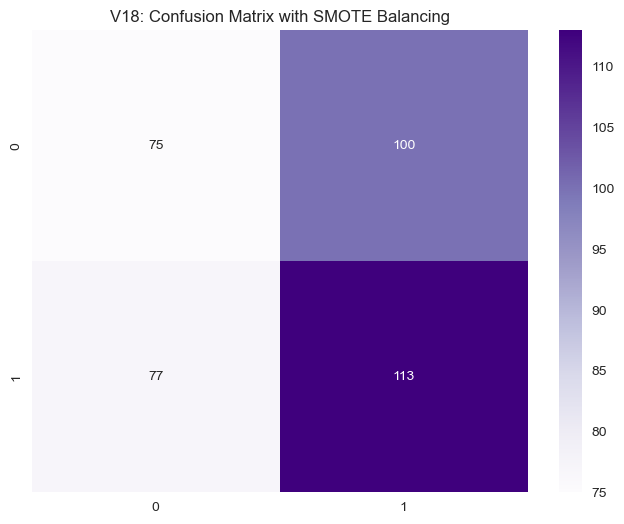

In [7]:
preds = xgb_balanced.predict(X_test)
cm = confusion_matrix(y_test, preds)

print("--- Balanced Model Performance ---")
print(classification_report(y_test, preds))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("V18: Confusion Matrix with SMOTE Balancing")
plt.show()